<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
%pip install -q requests nltk textblob wordcloud imageio matplotlib

In [7]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
# Newer NLTK releases separate this tokenizer table from punkt.
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
from collections import Counter
from io import BytesIO

import imageio.v3 as iio
import matplotlib.pyplot as plt
import requests
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

In [9]:
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'

response = requests.get(target_url, timeout=30)
response.raise_for_status()
data = response.text

print(f"Downloaded {len(data):,} characters.")
print(data[:250])

Downloaded 171,696 characters.
*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first


In [10]:
start_marker = '*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***'
end_marker = '*** END OF THE PROJECT GUTENBERG EBOOK 2265 ***'

start = data.find(start_marker)
end = data.find(end_marker)
hamlet_text = data[start + len(start_marker):end] if start != -1 and end != -1 else data

blob = TextBlob(hamlet_text)
print(f"Characters analyzed: {len(hamlet_text):,}")
print(f"Tokens found by TextBlob: {len(blob.words):,}")

Characters analyzed: 171,598
Tokens found by TextBlob: 30,723


In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

clean_words = [
    lemmatizer.lemmatize(word.lower())
    for word in blob.words
    if word.isalpha() and word.lower() not in stop_words
]

word_counts = Counter(clean_words)
top_20 = word_counts.most_common(20)

print(f"Words retained after cleaning: {len(clean_words):,}")
print(f"Unique cleaned words: {len(word_counts):,}")
print("\nTop 20 words:")
for rank, (word, count) in enumerate(top_20, start=1):
    print(f"{rank:2d}. {word:<15} {count:>4}")

Words retained after cleaning: 15,704
Unique cleaned words: 4,308

Top 20 words:
 1. ham              337
 2. lord             216
 3. king             181
 4. haue             175
 5. come             129
 6. hamlet           107
 7. let              107
 8. shall            107
 9. thou             105
10. good              98
11. hor               95
12. thy               90
13. enter             85
14. like              81
15. oh                81
16. father            71
17. well              70
18. make              70
19. may               69
20. know              69


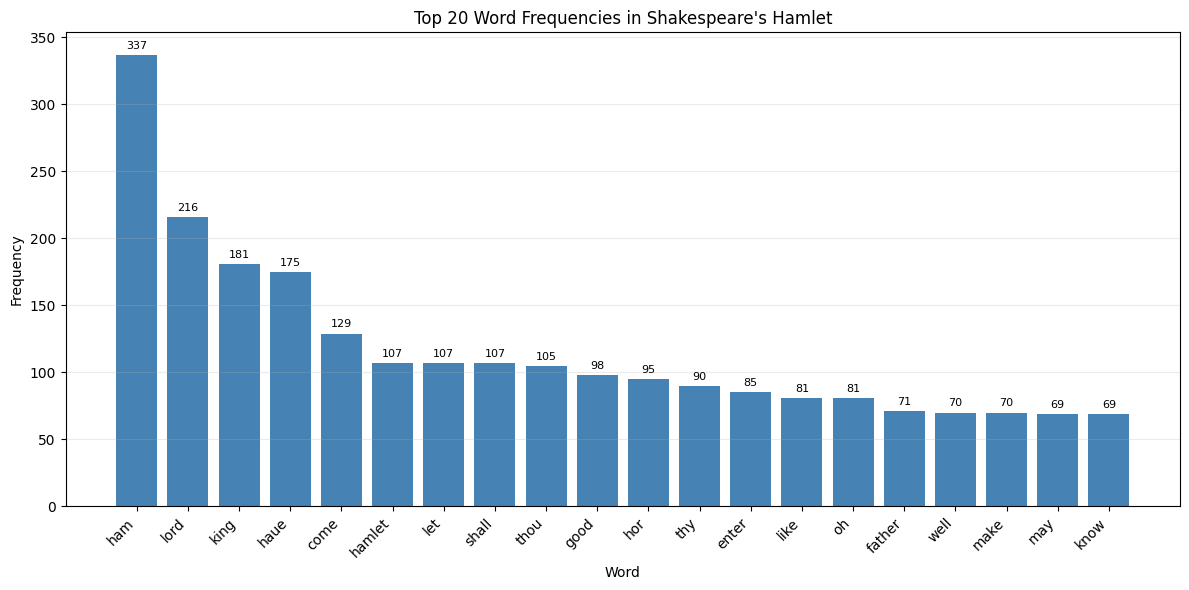

In [12]:
words, frequencies = zip(*top_20)

plt.figure(figsize=(12, 6))
bars = plt.bar(words, frequencies, color='steelblue')
plt.title("Top 20 Word Frequencies in Shakespeare's Hamlet")
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.bar_label(bars, padding=3, fontsize=8)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('hamlet_top_20_word_frequencies.png', dpi=200, bbox_inches='tight')
plt.show()

Mask shape: (1323, 2287, 3)


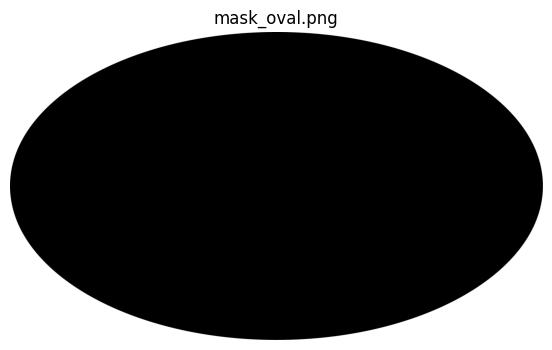

In [13]:
mask_url = (
    'https://raw.githubusercontent.com/pdeitel/IntroToPython/'
    'master/examples/ch12/mask_oval.png'
)

mask_response = requests.get(mask_url, timeout=30)
mask_response.raise_for_status()
mask_image = iio.imread(BytesIO(mask_response.content))
iio.imwrite('mask_oval.png', mask_image)

print('Mask shape:', mask_image.shape)
plt.figure(figsize=(7, 4))
plt.imshow(mask_image, cmap='gray')
plt.title('mask_oval.png')
plt.axis('off')
plt.show()

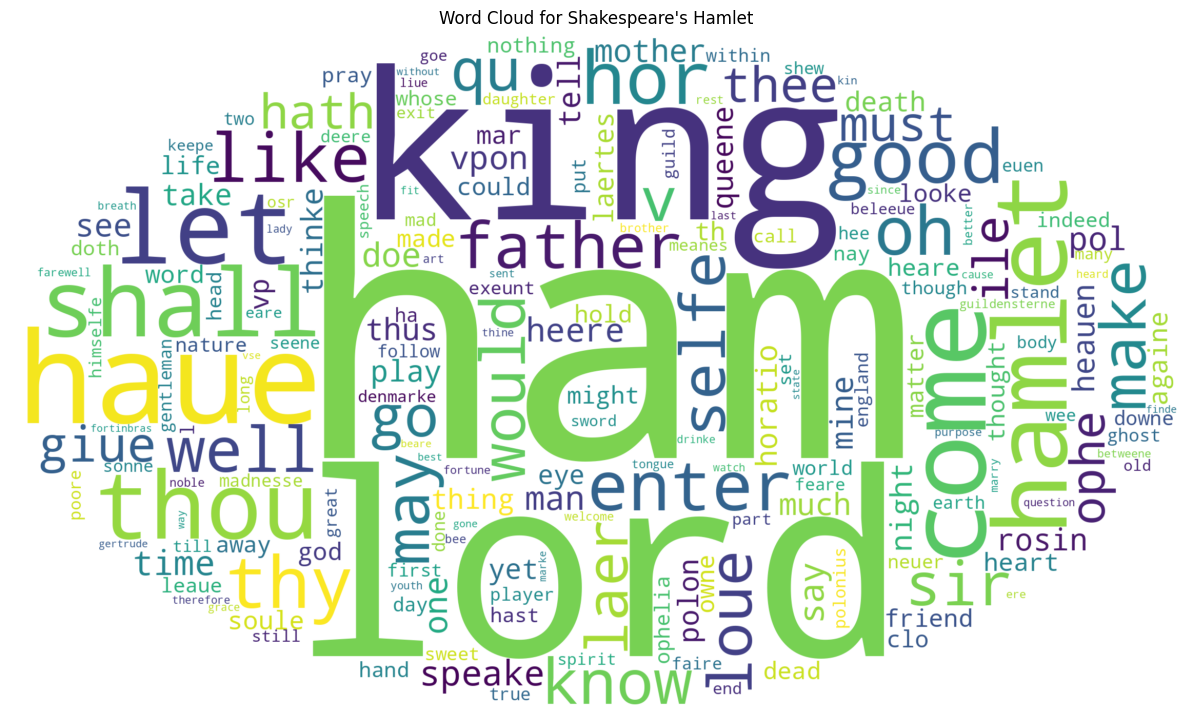

In [14]:
word_cloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    colormap='viridis',
    mask=mask_image,
    max_words=200,
    random_state=11,
).generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 7))
plt.imshow(word_cloud, interpolation='bilinear')
plt.title("Word Cloud for Shakespeare's Hamlet")
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('hamlet_word_cloud.png', dpi=200, bbox_inches='tight')
plt.show()